# 05 — LQR Control of an Inverted Pendulum on a Cart

**Section:** Motion Control · **Mirrors MATLAB:** *Multi-Loop PI Tuning for Robotic Arm* (LQR replaces PID here)

We balance a pendulum on a cart by linearizing around the upright equilibrium and solving the **continuous-time algebraic Riccati equation** for the optimal state-feedback gain `K = R⁻¹ Bᵀ P`.

Simulation uses the full **nonlinear** cart-pole dynamics — LQR is computed once from the linearization and remains stable over a wide region.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are

M, m, l, g = 1.0, 0.2, 0.5, 9.81

# Pendulum-UP convention: theta = 0 is the unstable upright equilibrium.
# Linearization at theta = 0:
A = np.array([[0, 1,             0, 0],
              [0, 0, -m * g / M,  0],
              [0, 0,             0, 1],
              [0, 0,  (M + m) * g / (M * l), 0]])
B = np.array([[0], [1 / M], [0], [-1 / (M * l)]])

Q = np.diag([1.0, 1.0, 10.0, 10.0])
R = np.array([[0.1]])

P = solve_continuous_are(A, B, Q, R)
K = np.linalg.inv(R) @ B.T @ P
print("LQR gain K =", K.flatten())


LQR gain K = [ -3.16227766  -6.21718017 -56.21609851 -15.64393849]


In [2]:
def nonlinear_dyn(x, u):
    # Pendulum-UP nonlinear cart-pole dynamics (theta = 0 is upright)
    pos, vel, th, om = x
    s, c = np.sin(th), np.cos(th)
    den = M + m * s ** 2
    acc = (u + m * l * s * om ** 2 - m * g * s * c) / den
    a_th = ((M + m) * g * s - u * c - m * l * s * c * om ** 2) / (l * den)
    return np.array([vel, acc, om, a_th])


x = np.array([0.0, 0.0, 0.35, 0.0])  # start ~20° off upright
T = 5.0; dt = 0.005
N = int(T / dt)
xs = np.zeros((N, 4)); us = np.zeros(N)
for i in range(N):
    u = float(-(K @ x).item())
    us[i] = u
    xs[i] = x
    x = x + dt * nonlinear_dyn(x, u)


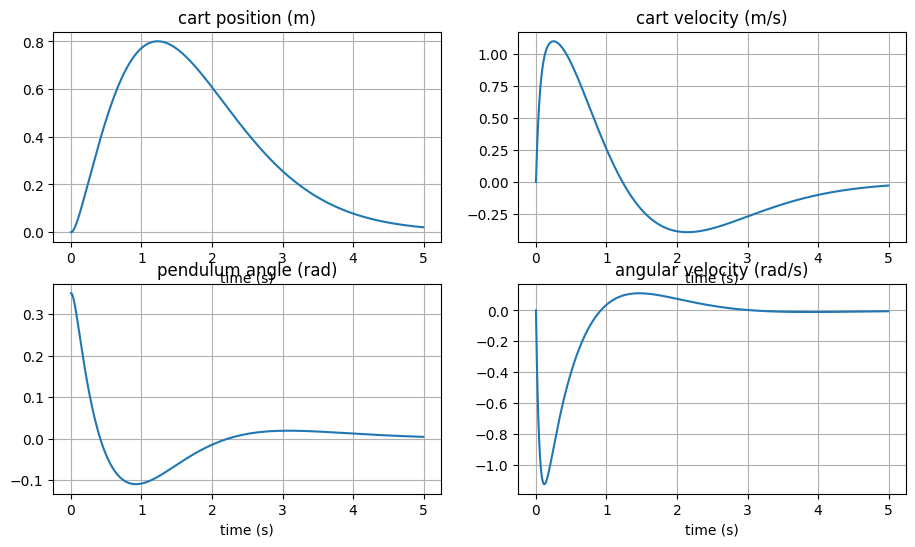

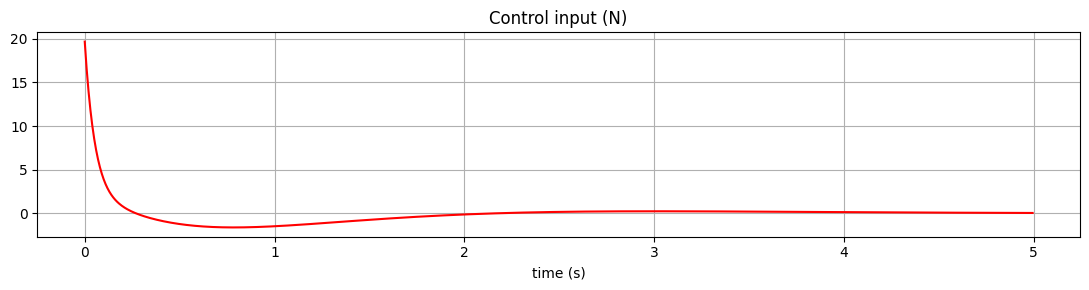

In [3]:
t = np.arange(N) * dt
fig, axs = plt.subplots(2, 2, figsize=(11, 6))
labels = ['cart position (m)', 'cart velocity (m/s)', 'pendulum angle (rad)', 'angular velocity (rad/s)']
for k, ax in enumerate(axs.flat):
    if k < 4:
        ax.plot(t, xs[:, k])
        ax.set_title(labels[k]); ax.set_xlabel('time (s)'); ax.grid()

fig2, ax2 = plt.subplots(figsize=(11, 3))
ax2.plot(t, us, 'r')
ax2.set_title('Control input (N)'); ax2.set_xlabel('time (s)'); ax2.grid()
plt.tight_layout()
plt.show()
